# Auditing the record before the paper: `eval.py` demo

This notebook is a runnable walk-through of **`eval.py`**, the assembly step of the iteration-3 *record audit* (artifact `art_7W9xiIO3FVBs`) in the project
*Exploring emerging scientific concepts through evolving knowledge networks* (OpenAlex concepts, temporal network indicators, emergence outcomes O1–O5).

The audit adds no new data. It checks every number that the iteration-2 paper draft reports against the file and key path that produced it,
and it re-checks the frames, bootstrap CIs and external-recognition ground truth behind those numbers. The five work packages (WP1–WP5) each
write a table or JSON. `eval.py:assemble()` then gathers them into one `eval_out.json` (schema `exp_eval_sol_out`) with:

* **`metrics_agg`**: ledger status counts, Exp5/Exp6 frame agreement (onset, home-field kappa, O2r Spearman, retention kappa), O5 external-recognition
  validity (held-out base rate, pooled rho against publication outcomes, hand-check precision / false-negative rate), next-field (Exp6) trace reproductions,
  and refit-bootstrap CIs for the iteration-1 deltas;
* **`datasets`**: per-example rows for the claims ledger, refit bootstrap, next-field trace, frame agreement on shared concepts, O5 per concept and the O5 hand check.

**What the demo changes:** the original reads its inputs from the run's folders (`claims_ledger.csv`, `results/*.json`, `record_tables/*`, and Exp5/Exp6 `frame_concepts.csv`).
Here those inputs come from `mini_demo_data.json`. The JSON summaries in that file are complete. Each per-row table is a subset of at most 100 rows, and the config cell
cuts it further. The notebook writes the inputs to a local folder, and **`assemble()` runs unchanged**.
The upstream stage scripts (`wp1_ledger.py`, `wp2_t3_refit.py`, …) are **not** re-run here, because they need the full multi-GB run record.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
# --- original eval.py imports ---
from __future__ import annotations

import argparse
import json
import math
import subprocess
import sys

import numpy as np
import pandas as pd
from loguru import logger

# --- original common.py imports (common.py is inlined below; eval.py uses it as `C`) ---
import hashlib
import os
from pathlib import Path

from scipy import stats

# --- notebook-only imports ---
import types
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/main/round-3/evaluation-2/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("full sizes in the original run:", data["full_sizes"])
print("tables in mini_demo_data.json:", {k: len(v) for k, v in data["csv_tables"].items()})

Inputs of eval.py:assemble() for the iteration-3 record audit (art_7W9xiIO3FVBs). JSON summaries are complete; per-row tables are subsets of <=100 rows (full sizes in 'full_sizes').
full sizes in the original run: {'claims_ledger.csv': 246, 'shared_frame_concepts': 628, 'o5_concept_panel.csv': 12499, 'o5_handcheck_items_final.csv': 100}
tables in mini_demo_data.json: {'claims_ledger.csv': 100, 'exp5/frame_concepts.csv': 100, 'exp6/results/frame_concepts.csv': 100, 'record_tables/o5_concept_panel.csv': 100, 'record_tables/o5_handcheck_items_final.csv': 100}


## Configuration

`assemble()` does no heavy computation. The main runtime cost is reading tables, so the only tunable parameters are the numbers of rows passed from each per-row table.
The largest value is 100 (all rows in `mini_demo_data.json`). The original run used the full tables: 246 ledger rows, 628 shared frame concepts, 12,499 O5 panel concepts and 100 hand-check items.
The JSON summaries (frame agreement, O5 validation core, hand-check summary, refit bootstrap, next-field trace) are always complete, so most `metrics_agg` values match the full run.
The ledger-count metrics and the per-example `datasets` reflect the subset.

In [5]:
N_LEDGER_ROWS = 100      # claims_ledger.csv rows      (original: 246 — all rows)
N_SHARED_CONCEPTS = 100  # Exp5∩Exp6 shared concepts   (original: 628)
N_PANEL_ROWS = 100       # o5_concept_panel.csv rows    (original: 12,499)
N_HANDCHECK_ITEMS = 100  # o5_handcheck_items_final.csv (original: 100)

DEMO_WS = Path("demo_ws")  # local stand-in for the artifact workspace; assemble() reads and writes here

## Write the inputs to a local workspace

This cell replaces the original file paths. It writes each input that `assemble()` reads to the relative path the original expects, with every table cut to the config sizes:

| original path | content |
|---|---|
| `claims_ledger.csv` | WP1 claims ledger (one row per number in the draft: source file, key path, re-read value, status, severity, correction) |
| `frame_agreement.json` | WP3 Exp5-vs-Exp6 frame agreement and the pooling verdict |
| `o5_definitions.json` | WP4 definitions of the external-recognition outcomes O5 |
| `results/o5_validation_core.json`, `results/o5_handcheck_summary.json` | WP4 O5 validation and the 100-item hand check |
| `results/t3_refit_bootstrap.json` | WP2-T3 refit-bootstrap CIs (B = 2000) for the iteration-1 deltas |
| `results/wp1_summary.json`, `results/inputs_manifest_*.json` | WP1 summary and per-stage input hashes |
| `record_tables/next_field_trace.json` | WP2-T4 trace of the 26 Exp6 headline numbers |
| `record_tables/o5_concept_panel.csv`, `record_tables/o5_handcheck_items_final.csv` | per-concept O5 panel and hand-check items |
| `exp5/frame_concepts.csv`, `exp6/results/frame_concepts.csv` | the Exp5 and Exp6 concept frames (iteration-2 artifacts) |

In [6]:
_n = {"claims_ledger.csv": N_LEDGER_ROWS, "exp5/frame_concepts.csv": N_SHARED_CONCEPTS, "exp6/results/frame_concepts.csv": N_SHARED_CONCEPTS,
      "record_tables/o5_concept_panel.csv": N_PANEL_ROWS, "record_tables/o5_handcheck_items_final.csv": N_HANDCHECK_ITEMS}
for rel_path, obj in data["json_files"].items():
    p = DEMO_WS / rel_path
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text(json.dumps(obj, indent=1))
for rel_path, rows in data["csv_tables"].items():
    p = DEMO_WS / rel_path
    p.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(rows).head(_n[rel_path]).to_csv(p, index=False)
# both frames hold the same concepts in the same order, so .head(N_SHARED_CONCEPTS) keeps the Exp5∩Exp6 overlap intact
print(sorted(str(p.relative_to(DEMO_WS)) for p in DEMO_WS.rglob("*") if p.is_file()))

['claims_ledger.csv', 'exp5/frame_concepts.csv', 'exp6/results/frame_concepts.csv', 'frame_agreement.json', 'o5_definitions.json', 'record_tables/next_field_trace.json', 'record_tables/o5_concept_panel.csv', 'record_tables/o5_handcheck_items_final.csv', 'results/inputs_manifest_wp1.json', 'results/inputs_manifest_wp2_t3.json', 'results/inputs_manifest_wp2_t4.json', 'results/inputs_manifest_wp3.json', 'results/inputs_manifest_wp4.json', 'results/inputs_manifest_wp4_extract.json', 'results/inputs_manifest_wp4_handcheck.json', 'results/o5_handcheck_summary.json', 'results/o5_validation_core.json', 'results/t3_refit_bootstrap.json', 'results/wp1_summary.json']


## Shared helpers (`common.py`)

`eval.py` does `import common as C`. The parts of `common.py` that `assemble()` uses are copied below unchanged, except for the path constants.
In the original, `WS` is the script's folder, `ROOT` is the run root and `E5`/`E6` point at the iteration-2 Exp5/Exp6 artifacts. Here they all point into `DEMO_WS`.
`norm_id` maps the two ID conventions to one: Exp5 stores integer concept IDs (`37253`) and Exp6 stores OpenAlex URLs (`https://openalex.org/C739882`). Both become `C…` IDs.
`jsonable` converts numpy types and non-finite floats so the output is valid JSON.

In [7]:
WS = DEMO_WS.resolve()  # original: Path(__file__).resolve().parent
ROOT = WS               # original: Path(os.environ.get("AII_RUN_ROOT", str(WS.parents[2]))).resolve()
SEED = 20260928
B_MAIN = 2000

E5 = WS / "exp5"          # original: ROOT / "iter_2/gen_art/gen_art_experiment_5"
E6 = WS / "exp6"          # original: ROOT / "iter_2/gen_art/gen_art_experiment_6"

RES = WS / "results"
TAB = WS / "record_tables"
LOGS = WS / "logs"
for _d in (RES, TAB, LOGS):
    _d.mkdir(exist_ok=True)

_READ: dict[str, str] = {}


def setup_logging(name: str) -> None:
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
    logger.add(LOGS / f"{name}.log", rotation="30 MB", level="DEBUG")


def rel(p: Path | str) -> str:
    """Path relative to ROOT (never absolute in outputs); workspace files relative to the workspace."""
    p = Path(p).resolve()
    try:
        return str(p.relative_to(WS))
    except ValueError:
        pass
    try:
        return str(p.relative_to(ROOT))
    except ValueError:
        return p.name


def track(p: Path) -> Path:
    """Record the sha256 of every input file read (inputs_manifest.json)."""
    k = rel(p)
    if k not in _READ and p.exists() and p.is_file():
        h = hashlib.sha256()
        with open(p, "rb") as f:
            for chunk in iter(lambda: f.read(1 << 22), b""):
                h.update(chunk)
        _READ[k] = h.hexdigest()
    return p


def read_json(p: Path):
    return json.loads(track(p).read_text())


def read_csv(p: Path, **kw) -> pd.DataFrame:
    return pd.read_csv(track(p), **kw)


def norm_id(x) -> str | None:
    """Exp5 integer 37253 -> 'C37253'; Exp6 'https://openalex.org/C739882' -> 'C739882'; 'C...' unchanged."""
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return None
    s = str(x).strip()
    if "/" in s:
        s = s.rstrip("/").split("/")[-1]
    if s.upper().startswith("C"):
        s = s[1:]
    if s.endswith(".0"):
        s = s[:-2]
    assert s.isdigit(), f"bad concept id {x!r}"
    return "C" + str(int(s))


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        v = float(o)
        return None if not math.isfinite(v) else v
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return jsonable(o.tolist())
    if isinstance(o, Path):
        return rel(o)
    return o


def dump(obj, path: Path) -> None:
    path.write_text(json.dumps(jsonable(obj), indent=1))


# notebook stand-in for `import common as C`
C = types.SimpleNamespace(WS=WS, ROOT=ROOT, SEED=SEED, B_MAIN=B_MAIN, E5=E5, E6=E6, RES=RES, TAB=TAB, LOGS=LOGS,
                          setup_logging=setup_logging, rel=rel, track=track, read_json=read_json, read_csv=read_csv,
                          norm_id=norm_id, jsonable=jsonable, dump=dump)

## Stages and value helpers (`eval.py`)

`STAGES` lists the work-package scripts that `uv run eval.py --stages all` runs before assembly. They are shown for reference but not run here (see the introduction).
`s()` turns a value into the string form that the `exp_eval_sol_out` schema requires for `input` / `output` / `predict_*` fields; non-finite floats become `"NaN"`.
`num()` returns a float only for finite numbers. `assemble()` uses it to drop non-numeric values from `metrics_agg`.

In [8]:
STAGES = [["wp2_t3_refit.py"], ["wp2_t4_nextfield.py"], ["wp3_frames.py"], ["wp4_extract.py"], ["wp4_o5.py"],
          ["wp4_handcheck.py", "--finalize"], ["wp1_ledger.py"]]


def s(x) -> str:
    if isinstance(x, float) and not math.isfinite(x):
        return "NaN"
    return x if isinstance(x, str) else json.dumps(C.jsonable(x))


def num(x) -> float | None:
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    return v if math.isfinite(v) else None

## `assemble()`: gather the audit into `eval_out.json`

This is the original function, unchanged. It works in four blocks:

1. **Read the stage outputs** (ledger, frame agreement, O5 validation core, hand-check summary, refit bootstrap, next-field trace, WP1 summary, O5 definitions).
   Then write the combined `o5_validation.json`.
2. **`metrics_agg`** is a flat dict of scalar metrics:
   * *ledger:* status counts (MATCH / MISMATCH / MISLABELLED / FILE_FLAG_OVERRIDDEN) and the number of blocking rows that carry a correction;
   * *frames (WP3):* onset agreement, home-field kappa, O1/O3 kappa, O2r_m50 Spearman and Lin CCC, episode Jaccard, and retention kappa under the Exp5 R rule and under the matched R_abs2 rule;
   * *O5 (WP4):* held-out base rate, pooled DerSimonian–Laird rho against the publication outcomes O2r_m50 and O1, the share of concepts already recognised by t0, and hand-check precision, date error and false-negative rate;
   * *next-field (WP2-T4):* the reproduced likelihood-ratio statistics (Breslow and exact);
   * *refit bootstrap (WP2-T3):* the point value and 95% CI for each iteration-1 delta.
3. **`datasets`**: six example lists, one row per claim, refit row, traced quantity, shared concept, O5 panel concept and hand-check item.
   Each row carries `input` / `output` / `predict_*` strings and numeric `eval_*` fields (e.g. `eval_match`, `eval_onset_exact`, `eval_positive_correct`).
4. **metadata**: plan ID, resampling unit, bootstrap settings, ledger counts, pooling verdict, O5 readings and next-field clash resolutions.
   Then write `eval_out.json` and the combined `inputs_manifest.json`.

In [9]:
def assemble() -> dict:
    led = pd.read_csv(C.WS / "claims_ledger.csv")
    fa = json.loads((C.WS / "frame_agreement.json").read_text())
    core = json.loads((C.RES / "o5_validation_core.json").read_text())
    hc = json.loads((C.RES / "o5_handcheck_summary.json").read_text())
    t3 = json.loads((C.RES / "t3_refit_bootstrap.json").read_text())
    tr = json.loads((C.TAB / "next_field_trace.json").read_text())
    wp1 = json.loads((C.RES / "wp1_summary.json").read_text())
    defs = json.loads((C.WS / "o5_definitions.json").read_text())
    o5v = {"definitions_file": "o5_definitions.json", **core, "hand_check": hc}
    C.dump(o5v, C.WS / "o5_validation.json")
    ag = fa["agreement"]
    main = core["associations_pooled_heldout_DL"]["O5_main"]
    st = led.status.value_counts().to_dict()
    blocking_rows = led[led.severity == "blocking"]
    ma = {"n_ledger_rows": len(led), "n_match": st.get("MATCH", 0), "n_rounding": st.get("ROUNDING", 0), "n_mismatch": st.get("MISMATCH", 0),
          "n_missing": st.get("MISSING", 0) + st.get("MISSING_SOURCE", 0), "n_mislabelled": st.get("MISLABELLED", 0),
          "n_file_flag_overridden": st.get("FILE_FLAG_OVERRIDDEN", 0),
          "n_blocking_rows": len(blocking_rows),
          "n_blocking_fixed": int(blocking_rows.correction_text.fillna("").str.len().gt(0).sum() + blocking_rows.text_change_note.fillna("").str.len().gt(0).sum()
                                  - (blocking_rows.correction_text.fillna("").str.len().gt(0) & blocking_rows.text_change_note.fillna("").str.len().gt(0)).sum()),
          "n_draft_numbers_harvested": sum(wp1["harvest"].values()), "n_draft_numbers_auto_matched": wp1["harvest"].get("AUTO_MATCH", 0),
          "t1_n_portability_indicators": wp1["T1_n_indicators"], "n_partial_association_candidates": wp1["n_partial_candidates"],
          "frame_n_exp5": fa["n_exp5"], "frame_n_exp6": fa["n_exp6"], "frame_n_both": fa["n_both"],
          "onset_exact_agree": ag["onset_exact"]["value"], "onset_pm1_agree": ag["onset_pm1"]["value"],
          "home_kappa": ag["home_kappa_26"]["value"], "o1_kappa": ag["O1_kappa"]["value"], "o3_kappa": ag["O3_kappa"]["value"],
          "o2r_spearman": ag["O2r_m50"]["spearman"], "o2r_m50_lin_ccc": ag["O2r_m50"]["lin_ccc"],
          "early_volume_log_spearman": ag["early_volume_log"]["spearman"], "episode_jaccard_median": ag["episode_jaccard"]["median"],
          "episode_jaccard_pooled": ag["episode_jaccard"]["pooled"], "retention_kappa": ag["retention"]["kappa_R_vs_Rcj"],
          "retention_kappa_R_abs2_matched_definition": ag["retention"]["kappa_R_abs2_vs_Rcj"],
          "pooling_criteria_met": fa["pooling"]["n_met"],
          "o5_main_base_rate_heldout": core["base_rate_heldout"], "o5_main_base_rate_all": next(r["O5_main_rate"] for r in core["coverage_by_group"] if r["group"] == "ALL"),
          "o5_rho_O2r_pooled": main["rho_O2r_m50"]["pooled"], "o5_rho_O2r_pooled_ci_lo": main["rho_O2r_m50"]["ci95"][0],
          "o5_rho_O2r_pooled_ci_hi": main["rho_O2r_m50"]["ci95"][1], "o5_rho_O1_pooled": main["rho_O1"]["pooled"],
          "o5_rho_O1_pooled_ci_lo": main["rho_O1"]["ci95"][0], "o5_rho_O1_pooled_ci_hi": main["rho_O1"]["ci95"][1],
          "o5_rho_O2r_resid_pooled": main["rho_O2r_resid"]["pooled"], "o5_rho_logN_pooled": main["rho_log_N_outcome"]["pooled"],
          "o5_tax_rho_O2r_pooled": core["associations_pooled_heldout_DL"]["O5_tax"]["rho_O2r_m50"]["pooled"],
          "o5_share_recognised_at_or_before_t0": core["lag"]["_all_main_sources"]["n_excluded_recognised_at_or_before_t0"] / core["n_frame"],
          "o5_pos_precision": hc["positive_precision_strict"], "o5_pos_precision_lenient": hc["positive_precision_lenient_partial_counts"],
          "o5_neg_fn_rate": hc["negatives_false_negative_rate"], "o5_date_error_le1_share": hc["date_error_le_1y_share_all_checked"],
          "o5_executor_llm_kappa": hc["executor_vs_llm_kappa_same_concept"], "o5_fit_for_use": int(hc["FIT_FOR_USE"]),
          "llm_cost_usd": hc["llm"]["llm_cost_usd"],
          "next_field_LR_M1_vs_M0_reproduced": tr["trace"]["LR_M1_vs_M0_breslow"]["recomputed"],
          "next_field_LR_M2_vs_M0_reproduced": tr["trace"]["LR_M2_vs_M0_breslow"]["recomputed"],
          "next_field_LR_M2_vs_M0_exact": tr["trace"]["LR_M2_vs_M0_exact"]["recomputed"],
          "next_field_trace_matches": tr["n_trace_match"], "next_field_trace_checked": tr["n_trace_checked"]}
    for r in t3:
        k = r["row"].replace(".", "_")
        ma[f"t3_{k}_point"] = r["point_reproduced"]
        ma[f"t3_{k}_ci95_lo"] = r["ci95_refit"][0]
        ma[f"t3_{k}_ci95_hi"] = r["ci95_refit"][1]
    ma = {k.replace("-", "_").replace(".", "_"): float(v) for k, v in ma.items() if num(v) is not None}
    # ---------------- datasets
    ds = []
    ex = []
    for r in led.itertuples():
        e = {"input": s({"claim_id": r.claim_id, "draft_section": r.draft_section, "claim_text": r.claim_text, "quantity": r.quantity,
                         "reported_value": r.reported_value}),
             "output": s(r.source_value), "predict_status": str(r.status),
             "metadata_source_file": s(r.source_file), "metadata_key_path": s(r.key_path), "metadata_severity": r.severity,
             "metadata_artifact_id": r.artifact_id, "metadata_in_draft": bool(r.in_draft),
             "metadata_correction": s(r.correction_text) if isinstance(r.correction_text, str) else "",
             "eval_match": 1.0 if r.status in ("MATCH", "ROUNDING") else 0.0}
        if num(r.abs_diff) is not None:
            e["eval_abs_diff"] = float(r.abs_diff)
        ex.append(e)
    ds.append({"dataset": "claims_ledger", "examples": ex})
    ex = []
    for r in t3:
        ex.append({"input": s({"row": r["row"], "experiment": r["experiment"], "outcome": r["outcome"], "base": r["base_cols"], "cand": r["cand_cols"]}),
                   "output": s({"point_reported": r["point_reported"], "fixed_prediction_ci90": r["fixed_prediction_ci90"]}),
                   "predict_refit_bootstrap": s({"point": r["point_reproduced"], "ci90": r["ci90_refit"], "ci95": r["ci95_refit"], "B": r["B"]}),
                   "metadata_source_file": r["source_file"], "metadata_key_path": r["key_path"],
                   "eval_point_abs_diff": float(r["abs_diff"]), "eval_ci95_width": float(r["ci95_refit"][1] - r["ci95_refit"][0]),
                   **({"eval_ci_widening_ratio_90": float(r["ci_widening_ratio_90"])} if num(r["ci_widening_ratio_90"]) is not None else {})})
    ds.append({"dataset": "refit_bootstrap_iter1", "examples": ex})
    ex = []
    for k, v in tr["trace"].items():
        e = {"input": s({"quantity": k, "how": v.get("how")}), "output": s(v.get("reported")), "predict_recomputed": s(v.get("recomputed")),
             "metadata_source_file": s(v.get("source_file")), "metadata_key_path": s(v.get("key_path"))}
        if v.get("match") is not None:
            e["eval_match"] = 1.0 if v["match"] else 0.0
        ex.append(e)
    ds.append({"dataset": "next_field_trace", "examples": ex})
    # frame agreement per shared concept
    f5 = C.read_csv(C.E5 / "frame_concepts.csv")
    f6 = C.read_csv(C.E6 / "results/frame_concepts.csv")
    f5["id"] = f5.concept_id.map(C.norm_id)
    f6["id"] = f6.concept_id.map(C.norm_id)
    m = f5.merge(f6, on="id", suffixes=("_5", "_6"))
    ex = []
    for r in m.itertuples():
        h5 = int(float(str(r.home_5).replace("|", ";").split(";")[0]))
        ex.append({"input": s({"concept": r.id, "name": r.name_5, "exp5_split": r.split_5, "exp6_split": r.split_6}),
                   "output": s({"t0": r.t0_6, "home_primary": int(r.home_primary), "O2r_m50": r.O2r_m50}),
                   "predict_exp5_frame": s({"t0": r.t0_5, "home_primary": h5, "early_volume": r.early_volume}),
                   "metadata_group_exp5": r.group_5, "metadata_group_exp6": r.group_6,
                   "eval_onset_exact": float(r.t0_5 == r.t0_6), "eval_onset_abs_diff": float(abs(r.t0_5 - r.t0_6)),
                   "eval_home_agree": float(h5 == int(r.home_primary))})
    ds.append({"dataset": "frame_agreement_shared_concepts", "examples": ex})
    # O5 per concept (Exp5 frame)
    pan = C.read_csv(C.TAB / "o5_concept_panel.csv")
    ex = []
    for r in pan.itertuples():
        e = {"input": s({"concept": r.id, "name": r.name, "t0": int(r.t0), "group": r.gkey}),
             "output": s({"O1": r.O1, "O2r_m50": r.O2r_m50, "O3": r.O3}),
             "predict_O5_main": str(int(r.O5_main)), "predict_O5_wiki": str(int(r.O5_wiki)), "predict_O5_tax": str(int(r.O5_tax)),
             "metadata_split": r.split, "eval_O5_main": float(r.O5_main)}
        if num(r.O5_lag) is not None:
            e["eval_O5_lag"] = float(r.O5_lag)
        ex.append(e)
    ds.append({"dataset": "o5_exp5_frame", "examples": ex})
    it = C.read_csv(C.TAB / "o5_handcheck_items_final.csv")
    ex = []
    for r in it.itertuples():
        e = {"input": s({"item": r.item, "kind": r.kind, "concept": r.id, "name": r.name, "t0": r.t0, "source": r.source,
                         "entry_title": r.entry_title, "year": r.year}),
             "output": s({"final_same": getattr(r, "final_same", None), "final_fn": getattr(r, "final_fn", None)}),
             "predict_llm_same_concept": s(r.llm_same_concept), "predict_executor_same_concept": s(r.exec_same),
             "metadata_wiki_first_rev_year": s(r.wiki_first_rev_year), "metadata_bucket": r.bucket}
        if r.kind == "positive" and isinstance(getattr(r, "final_same", None), str):
            e["eval_positive_correct"] = 1.0 if r.final_same == "yes" else 0.0
        if r.kind == "negative" and isinstance(getattr(r, "final_fn", None), str):
            e["eval_false_negative"] = 1.0 if r.final_fn == "yes" else 0.0
        ex.append(e)
    ds.append({"dataset": "o5_hand_check", "examples": ex})
    meta = {"evaluation_name": "Checking the record before the paper (iteration-3 record audit)",
            "plan_id": "gen_plan_evaluation_1_idx4", "resampling_unit": "concept", "bootstrap": {"B": 2000, "seed": C.SEED},
            "path_convention": "source paths are relative to the run's 3_invention_loop directory; workspace outputs relative to this workspace",
            "dependencies": ["art_wxWssKSUR45f", "art_N-mpomDZZ1ln", "art_O7Dq4L02QnDN"],
            "read_by_path": ["art_lwI2DuRtQRZX", "iter_1 exp1/exp3/exp4", "iter_2 paper_draft.md", "iter_2 review_report"],
            "ledger_status_counts": st, "frame_agreement": {k: fa[k] for k in ("n_exp5", "n_exp6", "n_both", "pooling", "disagreement_attribution")},
            "exp5_minus_exp6": fa["exp5_minus_exp6"], "o5_readings": {v: p["reading"] for v, p in core["associations_pooled_heldout_DL"].items()},
            "o5_hand_check": {k: v for k, v in hc.items() if not isinstance(v, list)}, "o5_definitions": defs,
            "next_field_clashes": {k: tr[k] for k in ("strata_clash_resolution", "LR_clash_resolution", "d_clash_resolution")},
            "t3_refit": t3, "record_tables": sorted(p.name for p in C.TAB.iterdir()),
            "files": ["claims_ledger.csv", "frame_agreement.json", "o5_validation.json", "o5_definitions.json", "text_corrections.md",
                      "inputs_manifest.json", "record_tables/"]}
    out = {"metadata": C.jsonable(meta), "metrics_agg": ma, "datasets": ds}
    (C.WS / "eval_out.json").write_text(json.dumps(C.jsonable(out), indent=1))
    # combined inputs manifest
    man = {}
    for p in sorted(C.RES.glob("inputs_manifest_*.json")):
        man.update(json.loads(p.read_text()))
    (C.WS / "inputs_manifest.json").write_text(json.dumps(dict(sorted(man.items())), indent=1))
    logger.info(f"eval_out.json: {len(ma)} metrics, datasets {[ (d['dataset'], len(d['examples'])) for d in ds]}")
    return out

## Run it (the body of `main()`)

The original `main()` parses `--stages` and, for `all`, runs each script in `STAGES` as a subprocess. It then calls `assemble()`.
The notebook keeps the logging setup and the `assemble()` call and skips the argparse and subprocess steps.

In [10]:
C.setup_logging("eval")
# original: if a.stages == "all": for st in STAGES: subprocess.run([sys.executable, *st], check=True, cwd=C.WS)
out = assemble()

11:19:20|INFO   |eval_out.json: 74 metrics, datasets [('claims_ledger', 100), ('refit_bootstrap_iter1', 7), ('next_field_trace', 32), ('frame_agreement_shared_concepts', 100), ('o5_exp5_frame', 100), ('o5_hand_check', 100)]


## Results

The first table shows the headline audit metrics from `metrics_agg`. The ledger-count rows cover only the ledger rows passed in (the full 246-row counts appear next to them for comparison).
The figure has four panels:
**(a)** WP1 ledger status: demo subset next to the full ledger.
**(b)** WP3 Exp5-vs-Exp6 frame agreement on the 628 shared concepts. Retention kappa is low under the original rules (0.28) and near 1 under the matched R_abs2 rule, which is why the pooling verdict is PARTIAL.
**(c)** WP2-T3 refit-bootstrap 95% CIs for the iteration-1 deltas. Every CI includes 0.
**(d)** WP4 O5 external-recognition validity: hand-check precision and false-negative rate, next to the pooled correlations of O5 with the publication outcomes. Both correlations are close to 0.

In [11]:
ma = out["metrics_agg"]
meta = out["metadata"]
full_counts = data["json_files"]["results/wp1_summary.json"]["ledger_status_counts"]

rows = [("ledger rows (demo subset)", ma["n_ledger_rows"], data["full_sizes"]["claims_ledger.csv"]),
        ("  MATCH", ma["n_match"], full_counts.get("MATCH", 0)),
        ("  MISLABELLED", ma["n_mislabelled"], full_counts.get("MISLABELLED", 0)),
        ("  MISMATCH", ma["n_mismatch"], full_counts.get("MISMATCH", 0)),
        ("  FILE_FLAG_OVERRIDDEN", ma["n_file_flag_overridden"], full_counts.get("FILE_FLAG_OVERRIDDEN", 0))]
print(f"{'WP1 claims ledger':<40}{'demo':>10}{'full run':>10}")
for k, v, f in rows:
    print(f"{k:<40}{v:>10.0f}{f:>10}")

sections = {
    "WP3 frame agreement (Exp5 vs Exp6)": ["frame_n_both", "onset_exact_agree", "onset_pm1_agree", "home_kappa", "o2r_spearman",
                                           "episode_jaccard_median", "retention_kappa", "retention_kappa_R_abs2_matched_definition", "pooling_criteria_met"],
    "WP4 O5 external recognition": ["o5_main_base_rate_heldout", "o5_rho_O2r_pooled", "o5_rho_O2r_pooled_ci_lo", "o5_rho_O2r_pooled_ci_hi",
                                    "o5_rho_O1_pooled", "o5_share_recognised_at_or_before_t0", "o5_pos_precision", "o5_neg_fn_rate",
                                    "o5_date_error_le1_share", "o5_fit_for_use", "llm_cost_usd"],
    "WP2-T4 next-field trace (Exp6)": ["next_field_LR_M1_vs_M0_reproduced", "next_field_LR_M2_vs_M0_reproduced", "next_field_LR_M2_vs_M0_exact",
                                       "next_field_trace_matches", "next_field_trace_checked"],
}
for title, keys in sections.items():
    print(f"\n{title}")
    for k in keys:
        print(f"  {k:<48}{ma[k]:>10.4g}")
print("\npooling verdict:", meta["frame_agreement"]["pooling"]["verdict"], "| O5 readings:", meta["o5_readings"])

print("\nper-example datasets (eval_* means over the demo rows):")
for d in out["datasets"]:
    evk = sorted({k for e in d["examples"] for k in e if k.startswith("eval_")})
    means = {k: round(float(np.mean([e[k] for e in d["examples"] if k in e])), 3) for k in evk}
    print(f"  {d['dataset']:<34} n={len(d['examples']):<4} {means}")

WP1 claims ledger                             demo  full run
ledger rows (demo subset)                      100       246
  MATCH                                         78       224
  MISLABELLED                                   15        15
  MISMATCH                                       6         6
  FILE_FLAG_OVERRIDDEN                           1         1

WP3 frame agreement (Exp5 vs Exp6)
  frame_n_both                                           628
  onset_exact_agree                                   0.9761
  onset_pm1_agree                                     0.9889
  home_kappa                                          0.9897
  o2r_spearman                                        0.9977
  episode_jaccard_median                                   1
  retention_kappa                                     0.2801
  retention_kappa_R_abs2_matched_definition           0.9796
  pooling_criteria_met                                     3

WP4 O5 external recognition
  o5_main_base_rate_

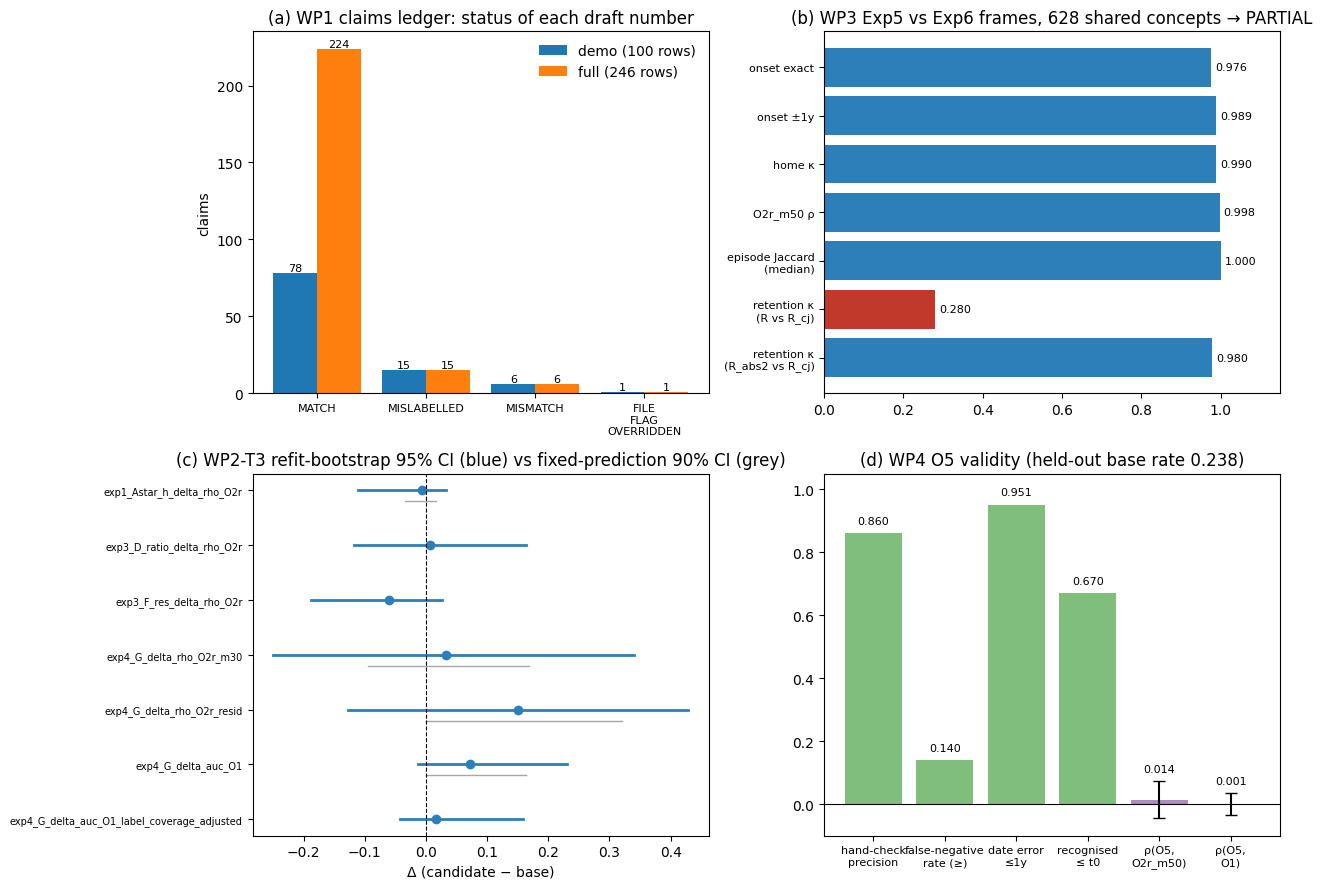

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) ledger status: demo subset vs full ledger
ax = axes[0, 0]
labs = ["MATCH", "MISLABELLED", "MISMATCH", "FILE_FLAG_OVERRIDDEN"]
demo_v = [meta["ledger_status_counts"].get(l, 0) for l in labs]
full_v = [full_counts.get(l, 0) for l in labs]
x = np.arange(len(labs))
ax.bar(x - 0.2, demo_v, 0.4, label=f"demo ({int(ma['n_ledger_rows'])} rows)")
ax.bar(x + 0.2, full_v, 0.4, label=f"full ({data['full_sizes']['claims_ledger.csv']} rows)")
for xi, (a, b) in enumerate(zip(demo_v, full_v)):
    ax.text(xi - 0.2, a, str(a), ha="center", va="bottom", fontsize=8)
    ax.text(xi + 0.2, b, str(b), ha="center", va="bottom", fontsize=8)
ax.set_xticks(x, [l.replace("_", "\n") for l in labs], fontsize=8)
ax.set_ylabel("claims")
ax.set_title("(a) WP1 claims ledger: status of each draft number")
ax.legend(frameon=False)

# (b) frame agreement
ax = axes[0, 1]
fk = [("onset exact", "onset_exact_agree"), ("onset ±1y", "onset_pm1_agree"), ("home κ", "home_kappa"), ("O2r_m50 ρ", "o2r_spearman"),
      ("episode Jaccard\n(median)", "episode_jaccard_median"), ("retention κ\n(R vs R_cj)", "retention_kappa"),
      ("retention κ\n(R_abs2 vs R_cj)", "retention_kappa_R_abs2_matched_definition")]
vals = [ma[k] for _, k in fk]
cols = ["#c0392b" if k == "retention_kappa" else "#2c7fb8" for _, k in fk]
ax.barh(range(len(fk)), vals, color=cols)
for i, v in enumerate(vals):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)
ax.set_yticks(range(len(fk)), [l for l, _ in fk], fontsize=8)
ax.invert_yaxis()
ax.set_xlim(0, 1.15)
ax.set_title(f"(b) WP3 Exp5 vs Exp6 frames, {int(ma['frame_n_both'])} shared concepts → {meta['frame_agreement']['pooling']['verdict']}")

# (c) refit bootstrap CIs
ax = axes[1, 0]
t3 = meta["t3_refit"]
for i, r in enumerate(t3):
    lo, hi = r["ci95_refit"]
    ax.plot([lo, hi], [i, i], color="#2c7fb8", lw=2)
    ax.plot(r["point_reproduced"], i, "o", color="#2c7fb8")
    if r.get("fixed_prediction_ci90") and all(v is not None for v in r["fixed_prediction_ci90"]):
        ax.plot(r["fixed_prediction_ci90"], [i + 0.2, i + 0.2], color="grey", lw=1, alpha=0.7)
ax.axvline(0, color="k", lw=0.8, ls="--")
ax.set_yticks(range(len(t3)), [r["row"] for r in t3], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("Δ (candidate − base)")
ax.set_title("(c) WP2-T3 refit-bootstrap 95% CI (blue) vs fixed-prediction 90% CI (grey)")

# (d) O5 external recognition validity
ax = axes[1, 1]
ok = [("hand-check\nprecision", ma["o5_pos_precision"], None), ("false-negative\nrate (≥)", ma["o5_neg_fn_rate"], None),
      ("date error\n≤1y", ma["o5_date_error_le1_share"], None), ("recognised\n≤ t0", ma["o5_share_recognised_at_or_before_t0"], None),
      ("ρ(O5,\nO2r_m50)", ma["o5_rho_O2r_pooled"], (ma["o5_rho_O2r_pooled_ci_lo"], ma["o5_rho_O2r_pooled_ci_hi"])),
      ("ρ(O5,\nO1)", ma["o5_rho_O1_pooled"], (ma["o5_rho_O1_pooled_ci_lo"], ma["o5_rho_O1_pooled_ci_hi"]))]
for i, (l, v, ci) in enumerate(ok):
    ax.bar(i, v, color="#7fbf7b" if ci is None else "#af8dc3",
           yerr=None if ci is None else [[v - ci[0]], [ci[1] - v]], capsize=4)
    ax.text(i, (max(v, 0) if ci is None else ci[1]) + 0.03, f"{v:.3f}", ha="center", fontsize=8)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(len(ok)), [l for l, _, _ in ok], fontsize=8)
ax.set_ylim(-0.1, 1.05)
ax.set_title(f"(d) WP4 O5 validity (held-out base rate {ma['o5_main_base_rate_heldout']:.3f})")

plt.tight_layout()
plt.show()